<a href="https://colab.research.google.com/github/SaiSriHarsha2006/MS-01/blob/main/supervisedLearning_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


X,y=make_classification(n_samples=1000,n_features=5,n_informatives=15,n_redudant=0,random_state=40)
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=40)
pipeline=Pipeline([
    ('scalar',StandardScalar()),
    ('classifier',LogisticRegression(random_state=40,max_iter=1000,C=1.0,penalty='l2'))

])
pipeline.fit(x_train,y_train)
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ============================================
# STEP 6: PREDICT ON NEW DATA
# ============================================
new_data = np.array([[1.2, -0.5, 0.8, 2.1, -0.3]])
prediction = pipeline.predict(new_data)
probability = pipeline.predict_proba(new_data)

print(f"\nNew sample prediction: Class {prediction[0]}")
print(f"Probability: {probability[0]}")





TypeError: got an unexpected keyword argument 'n_informatives'

In [1]:
# ============================================
# STEP 1: IMPORTS
# ============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================
# STEP 2: CREATE SAMPLE DATA (or load your own)
# ============================================
# Creating a synthetic dataset for demonstration
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=2,
    random_state=42
)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# STEP 3: BUILD THE PIPELINE
# ============================================
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Step 1: Scale features
    ('classifier', LogisticRegression(      # Step 2: Logistic Regression
        random_state=42,
        max_iter=1000,
        C=1.0,                              # Regularization strength (inverse)
        penalty='l2'                        # L2 regularization
    ))
])

# ============================================
# STEP 4: TRAIN THE PIPELINE
# ============================================
pipeline.fit(X_train, y_train)

# ============================================
# STEP 5: PREDICT & EVALUATE
# ============================================
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ============================================
# STEP 6: PREDICT ON NEW DATA
# ============================================
new_data = np.array([[1.2, -0.5, 0.8, 2.1, -0.3]])
prediction = pipeline.predict(new_data)
probability = pipeline.predict_proba(new_data)

print(f"\nNew sample prediction: Class {prediction[0]}")
print(f"Probability: {probability[0]}")

Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92        94
           1       0.94      0.92      0.93       106

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200


Confusion Matrix:
 [[88  6]
 [ 9 97]]

New sample prediction: Class 1
Probability: [0.02915157 0.97084843]


### Visualizing the Decision Boundary

To visualize the decision boundary of the Logistic Regression model, we need to reduce the dimensionality to 2D. We will select the first two features and plot the decision boundary based on these, assuming the other features are held constant (or using a suitable projection strategy). For simplicity, we'll project the data onto the first two features and visualize the boundary in that space.

First, let's ensure we have `matplotlib` and `seaborn` imported, which are already present in the notebook context.

/tmp/ipykernel_615/46870189.py:48: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=50, label='Test data')


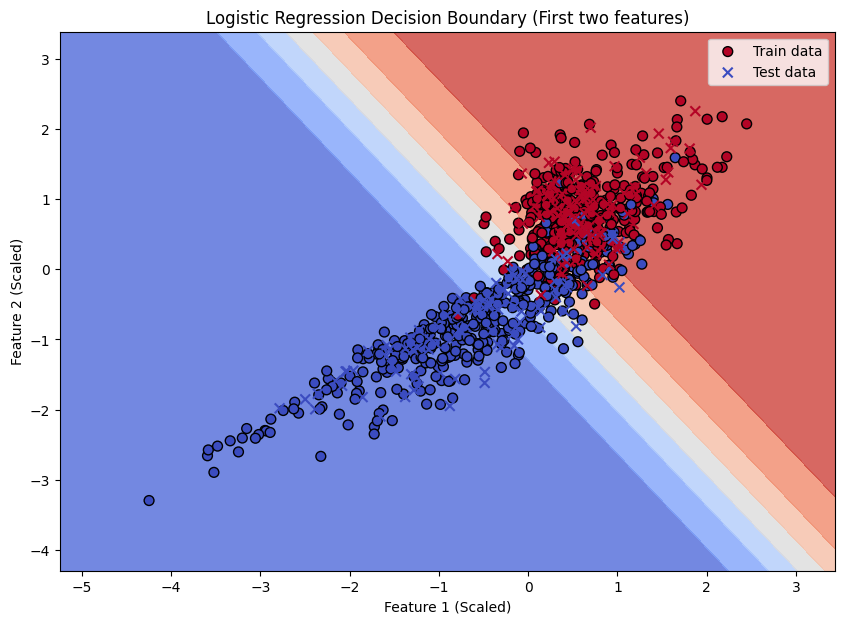

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the pipeline's scaler was fitted on X_train
# We need to transform X_train and X_test using the fitted scaler from the pipeline
scaler = pipeline.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For visualization, we'll use only the first two features
X_train_2d = X_train_scaled[:, :2]
X_test_2d = X_test_scaled[:, :2]

# Create a simplified model for 2D visualization (optional, but cleaner for plotting)
# Alternatively, we can use the main pipeline's classifier directly, but it expects 5 features.
# Let's create a temporary 2-feature classifier if the original model cannot predict on 2 features.
# If the original pipeline's classifier can be called with only 2 features (e.g., it's a simple classifier),
# then we can use it. However, the StandardScaler needs to be part of the pipeline when predicting.

# To make the full pipeline predict on 2 features, we need to adapt it. A more robust way is:
# 1. Train a new simple Logistic Regression model on the first two features of the scaled data.
# 2. Use the original pipeline's classifier on a modified meshgrid.

# Let's create a meshgrid to plot the decision boundary for the first two features.
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# To predict on the meshgrid, we need to create a dummy array with 5 features, where the last 3 are 0
# or some mean/median value if we want to be more precise. For simplicity, we'll use zeros.
# This is a simplification; a proper projection method like PCA would be better for high-dim visualization.
Z_input = np.zeros((xx.ravel().shape[0], X_train_scaled.shape[1]))
Z_input[:, 0] = xx.ravel()
Z_input[:, 1] = yy.ravel()

# Predict class probabilities for the meshgrid points using the full pipeline
# Note: The pipeline expects 5 features, so we have to feed it 5 features, even if 3 are constant.
Z = pipeline.predict_proba(Z_input)[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot training points
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=50, label='Train data')
# Plot test points
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=50, label='Test data')

plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.title('Logistic Regression Decision Boundary (First two features)')
plt.legend()
plt.show()

Training samples: 711
Test samples: 178
Class distribution:
survived
0    549
1    340
Name: count, dtype: int64

🔍 Training model with GridSearch...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best parameters: {'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
✅ Best CV ROC-AUC: 0.8466

MODEL PERFORMANCE ON TEST SET
Accuracy: 0.7865
ROC-AUC Score: 0.8508

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.86      0.78      0.82       110
    Survived       0.69      0.79      0.74        68

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178



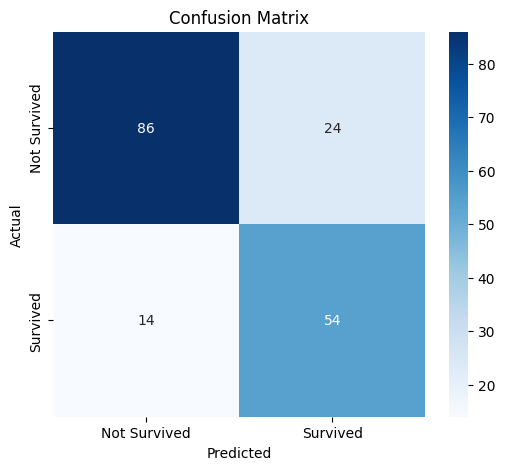

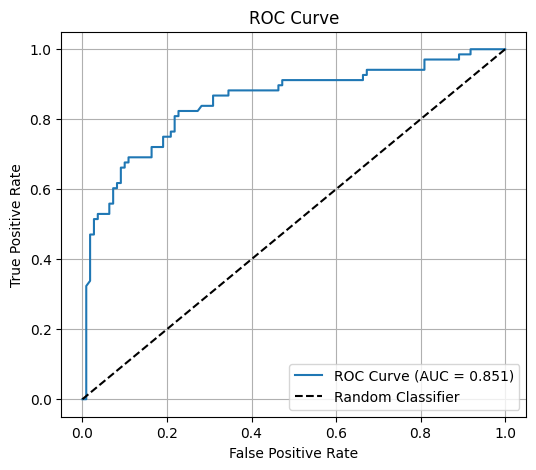


TOP 10 FEATURE IMPORTANCE
      Feature  Coefficient  Odds_Ratio
5  sex_female     1.386175    3.999522
2    pclass_1     1.056776    2.877081
6    sex_male    -1.047561    0.350792
4    pclass_3    -0.897470    0.407599
0         age    -0.394097    0.674289
8  embarked_Q     0.385222    1.469941
9  embarked_S    -0.245916    0.781988
7  embarked_C     0.199308    1.220558
3    pclass_2     0.179308    1.196389
1        fare     0.068428    1.070824


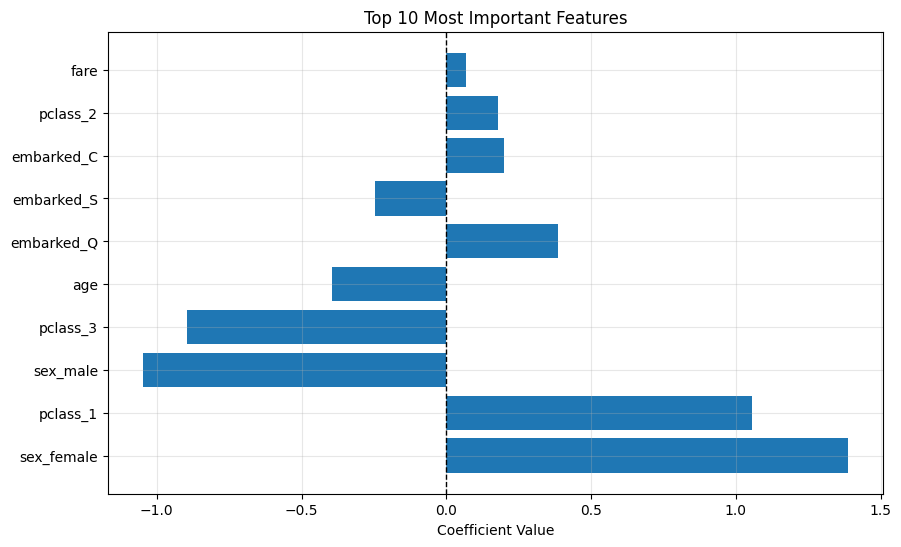


5-Fold Cross-Validation Accuracy: 0.7764 (+/- 0.0344)

✅ Model saved as 'logistic_regression_model.pkl'

PREDICTIONS FOR NEW PASSENGERS
Passenger 1: ✅ Survived (Probability: 95.68%)
Passenger 2: ❌ Not Survived (Probability: 11.36%)
Passenger 3: ✅ Survived (Probability: 91.15%)


In [5]:
# ============================================
# STEP 1: IMPORTS
# ============================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 2: LOAD REAL DATA (Titanic)
# ============================================
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]
df = df.dropna(subset=['embarked'])  # Drop rows with missing embarked

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Class distribution:\n{y.value_counts()}")

# ============================================
# STEP 3: DEFINE PREPROCESSING PIPELINES
# ============================================
# Identify column types
numeric_features = ['age', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']

# Numeric pipeline: Impute missing with median, then scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute missing with mode, then one-hot encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ============================================
# STEP 4: BUILD FULL PIPELINE
# ============================================
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'  # Handles imbalanced classes
    ))
])

# ============================================
# STEP 5: HYPERPARAMETER TUNING WITH GRID SEARCH
# ============================================
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']  # Both support L1 and L2
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,                      # 5-fold cross-validation
    scoring='roc_auc',         # Better for imbalanced data
    n_jobs=-1,
    verbose=1
)

print("\n🔍 Training model with GridSearch...")
grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# ============================================
# STEP 6: EVALUATE ON TEST SET
# ============================================
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("MODEL PERFORMANCE ON TEST SET")
print("="*60)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# STEP 7: FEATURE IMPORTANCE (Coefficients)
# ============================================
# Extract the logistic regression model
logreg = best_model.named_steps['classifier']

# Get feature names after preprocessing
preprocessor_obj = best_model.named_steps['preprocessor']
num_features = numeric_features
cat_features = preprocessor_obj.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = list(num_features) + list(cat_features)

# Extract coefficients
coefficients = logreg.coef_[0]

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
})
importance_df['Abs_Coefficient'] = np.abs(importance_df['Coefficient'])
importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

print("\n" + "="*60)
print("TOP 10 FEATURE IMPORTANCE")
print("="*60)
print(importance_df[['Feature', 'Coefficient', 'Odds_Ratio']].head(10))

# Visualize
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)
bars = plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Most Important Features')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# STEP 8: CROSS-VALIDATION SCORE
# ============================================
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# ============================================
# STEP 9: SAVE & LOAD MODEL FOR DEPLOYMENT
# ============================================
import joblib

# Save the model
joblib.dump(best_model, 'logistic_regression_model.pkl')
print("\n✅ Model saved as 'logistic_regression_model.pkl'")

# Load and test
loaded_model = joblib.load('logistic_regression_model.pkl')

# Test with new data
new_passengers = pd.DataFrame({
    'pclass': [1, 3, 2],
    'sex': ['female', 'male', 'female'],
    'age': [28, 35, np.nan],
    'fare': [85.0, 8.5, 32.0],
    'embarked': ['C', 'S', 'Q']
})

predictions = loaded_model.predict(new_passengers)
probabilities = loaded_model.predict_proba(new_passengers)

print("\n" + "="*60)
print("PREDICTIONS FOR NEW PASSENGERS")
print("="*60)
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    survival = "✅ Survived" if pred == 1 else "❌ Not Survived"
    print(f"Passenger {i+1}: {survival} (Probability: {prob[1]:.2%})")

In [ ]:
import kagglehub
path = kagglehub.dataset_download("heptapod/titanic")